# Dual-Stream Real / Fake Image Detector — Kaggle Edition
**Dataset:** CIFAKE (built into Kaggle — no download needed)
**Architecture:** EfficientNet-B4 + FFT-CNN + Cross-attention fusion

---
### Before you start
1. Go to Settings (right panel) -> Accelerator -> GPU T4 x2
2. Add CIFAKE dataset: Add Data -> Search 'CIFAKE' -> Add
3. Run all cells top to bottom

## Cell 1 — Check GPU

In [1]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device        : {device}')
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    print(f'GPUs available: {n_gpus}')
    for i in range(n_gpus):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}  '
              f'({torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB)')
else:
    print('WARNING: No GPU found. Enable GPU in Settings -> Accelerator')


Device        : cuda
GPUs available: 2
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)


## Cell 2 — Locate CIFAKE dataset

In [2]:
import os
from pathlib import Path

# Your CIFAKE is mounted at this path
CIFAKE_ROOT = Path('/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images')

# Verify it exists and show structure
if CIFAKE_ROOT.exists():
    print(f'CIFAKE found at: {CIFAKE_ROOT}')
    print('\nContents:')
    for root, dirs, files in os.walk(CIFAKE_ROOT):
        level = str(root).replace(str(CIFAKE_ROOT), '').count(os.sep)
        if level > 2:
            continue
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 3 and files:
            print(f'{indent}  ({len(files)} files)')
else:
    print(f'ERROR: Path not found: {CIFAKE_ROOT}')
    print('\nAll available paths:')
    for p in Path('/kaggle/input').rglob('*'):
        if p.is_dir():
            print(f'  {p}')

CIFAKE found at: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images

Contents:
cifake-real-and-ai-generated-synthetic-images/
  test/
    FAKE/
      (10000 files)
    REAL/
      (10000 files)
  train/
    FAKE/
      (50000 files)
    REAL/
      (50000 files)


## Cell 3 — Set dataset paths

In [3]:
import os, shutil
from pathlib import Path

# Output paths
WORKING    = Path('/kaggle/working')
TRAIN_DIR  = WORKING / 'train'
VAL_DIR    = WORKING / 'val'
MODEL_PATH = str(WORKING / 'model.pt')
LOG_PATH   = str(WORKING / 'training_log.csv')

# Updated paths matching your Kaggle mount
CIFAKE_TRAIN = CIFAKE_ROOT / 'train'
CIFAKE_TEST  = CIFAKE_ROOT / 'test'

# Check folders exist
print(f'Train folder exists: {CIFAKE_TRAIN.exists()}')
print(f'Test folder  exists: {CIFAKE_TEST.exists()}')

# Show what is inside
for split in [CIFAKE_TRAIN, CIFAKE_TEST]:
    if split.exists():
        for cls in sorted(split.iterdir()):
            if cls.is_dir():
                count = len(list(cls.iterdir()))
                print(f'  {split.name}/{cls.name}/  ({count} images)')

# Copy into working directory with lowercase folder names
MAPPING = [
    (CIFAKE_TRAIN / 'REAL', TRAIN_DIR / 'real'),
    (CIFAKE_TRAIN / 'FAKE', TRAIN_DIR / 'fake'),
    (CIFAKE_TEST  / 'REAL', VAL_DIR   / 'real'),
    (CIFAKE_TEST  / 'FAKE', VAL_DIR   / 'fake'),
]

print('\nCopying dataset to working directory...')
total_copied = 0

for src, dst in MAPPING:
    dst.mkdir(parents=True, exist_ok=True)
    if not src.exists():
        print(f'WARNING: not found: {src}')
        continue
    files = [f for f in src.iterdir()
             if f.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    for f in files:
        shutil.copy2(f, dst / f.name)
    total_copied += len(files)
    print(f'  {src.name} -> {dst.name}/  ({len(files)} images)')

print(f'\nTotal images : {total_copied}')
print(f'TRAIN_DIR    : {TRAIN_DIR}')
print(f'VAL_DIR      : {VAL_DIR}')
print(f'MODEL_PATH   : {MODEL_PATH}')
print('\nDataset ready. Continue to Cell 4.')

Train folder exists: True
Test folder  exists: True
  train/FAKE/  (50000 images)
  train/REAL/  (50000 images)
  test/FAKE/  (10000 images)
  test/REAL/  (10000 images)

Copying dataset to working directory...
  REAL -> real/  (50000 images)
  FAKE -> fake/  (50000 images)
  REAL -> real/  (10000 images)
  FAKE -> fake/  (10000 images)

Total images : 120000
TRAIN_DIR    : /kaggle/working/train
VAL_DIR      : /kaggle/working/val
MODEL_PATH   : /kaggle/working/model.pt

Dataset ready. Continue to Cell 4.


## Cell 4 — Install dependencies

In [4]:
!pip install -q scikit-learn tqdm
print('Dependencies ready.')


Dependencies ready.


## Cell 5 — Model architecture

In [5]:
import torch
import torch.nn as nn
from torchvision import models


class FrequencyStream(nn.Module):
    """Lightweight CNN on FFT magnitude spectrum."""
    def __init__(self, out_dim=256):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(256, out_dim)

    def _to_spectrum(self, x):
        fft = torch.fft.fft2(x, norm='ortho')
        mag = torch.fft.fftshift(torch.abs(fft), dim=(-2, -1))
        mag = torch.log1p(mag)
        mn  = mag.flatten(2).min(dim=-1).values[..., None, None]
        mx  = mag.flatten(2).max(dim=-1).values[..., None, None]
        return (mag - mn) / (mx - mn + 1e-8)

    def forward(self, x):
        return self.proj(self.cnn(self._to_spectrum(x)).flatten(1))


class SpatialStream(nn.Module):
    """EfficientNet-B4 with last 3 blocks unfrozen."""
    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B4_Weights.DEFAULT if pretrained else None
        eff = models.efficientnet_b4(weights=weights)
        self.features = eff.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        for p in self.features.parameters():
            p.requires_grad = False
        for block in list(self.features.children())[-3:]:
            for p in block.parameters():
                p.requires_grad = True

    def forward(self, x):
        return self.pool(self.features(x)).flatten(1)


class CrossAttentionFusion(nn.Module):
    """Learned gate that weights spatial vs frequency contributions."""
    def __init__(self, spatial_dim=1792, freq_dim=256, embed_dim=512):
        super().__init__()
        total = spatial_dim + freq_dim
        self.gate = nn.Sequential(
            nn.Linear(total, total // 4), nn.ReLU(),
            nn.Linear(total // 4, total), nn.Sigmoid(),
        )
        self.proj = nn.Sequential(
            nn.Linear(total, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
        )

    def forward(self, spatial, freq):
        combined = torch.cat([spatial, freq], dim=-1)
        return self.proj(combined * self.gate(combined))


class DualStreamDetector(nn.Module):
    def __init__(self, pretrained=True, freq_dim=256, embed_dim=512, dropout=0.4):
        super().__init__()
        self.spatial_stream = SpatialStream(pretrained=pretrained)
        self.freq_stream    = FrequencyStream(out_dim=freq_dim)
        self.fusion         = CrossAttentionFusion(1792, freq_dim, embed_dim)
        self.classifier     = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(
            self.fusion(self.spatial_stream(x), self.freq_stream(x))
        ).squeeze(1)


print('Model classes defined.')


Model classes defined.


## Cell 6 — Dataset and DataLoaders

In [6]:
import warnings
from PIL import Image, ImageFile
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.MAX_IMAGE_PIXELS = None
warnings.filterwarnings('ignore', category=UserWarning, module='PIL')

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}


def get_transforms(split, img_size=224):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])


class RealFakeDataset(Dataset):
    def __init__(self, root, split='train', img_size=224):
        self.transform = get_transforms(split, img_size)
        self.samples   = []
        for label, cls in enumerate(['real', 'fake']):
            cls_dir = Path(root) / cls
            if not cls_dir.exists():
                raise FileNotFoundError(f'Missing folder: {cls_dir}')
            for f in sorted(cls_dir.iterdir()):
                if f.suffix.lower() in EXTENSIONS:
                    self.samples.append((f, label))
        real_n = sum(1 for _, l in self.samples if l == 0)
        fake_n = sum(1 for _, l in self.samples if l == 1)
        print(f'[{split}] {len(self.samples)} images  (real={real_n}, fake={fake_n})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path)
            if img.mode == 'P':
                img = img.convert('RGBA')
            img = img.convert('RGB')
        except Exception as e:
            print(f'Warning: bad image {path}: {e}')
            img = Image.new('RGB', (224, 224), (0, 0, 0))
        return self.transform(img), label


BATCH_SIZE  = 64
IMG_SIZE    = 224
NUM_WORKERS = 4

train_ds = RealFakeDataset(TRAIN_DIR, split='train', img_size=IMG_SIZE)
val_ds   = RealFakeDataset(VAL_DIR,   split='val',   img_size=IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print('DataLoaders ready.')


[train] 100000 images  (real=50000, fake=50000)
[val] 20000 images  (real=10000, fake=10000)
DataLoaders ready.


## Cell 7 — Training configuration

In [7]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS     = 20
PATIENCE   = 5
THRESHOLD  = 0.55
LR_SPATIAL = 1e-5
LR_OTHER   = 1e-4

# Build model
model = DualStreamDetector(pretrained=True)

# Use both GPUs if available
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs in parallel')
    model = nn.DataParallel(model)

model = model.to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device     : {device}')
print(f'Parameters : {total_p:,} total  |  {trainable_p:,} trainable')

criterion = nn.BCEWithLogitsLoss()

# Get base model params whether wrapped in DataParallel or not
base_model = model.module if hasattr(model, 'module') else model
spatial_params = list(base_model.spatial_stream.parameters())
other_params   = (list(base_model.freq_stream.parameters()) +
                  list(base_model.fusion.parameters()) +
                  list(base_model.classifier.parameters()))

optimizer = AdamW([
    {'params': spatial_params, 'lr': LR_SPATIAL, 'weight_decay': 1e-4},
    {'params': other_params,   'lr': LR_OTHER,   'weight_decay': 1e-4},
])
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

print('Optimiser ready.')


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 159MB/s]


Using 2 GPUs in parallel
Device     : cuda
Parameters : 21,219,401 total  |  17,583,417 trainable
Optimiser ready.


## Cell 8 — Train

In [8]:
import csv, time
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)


def run_epoch(model, loader, criterion, optimizer, train):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad if train else torch.no_grad
    with ctx():
        pbar = tqdm(loader, desc='train' if train else 'val  ',
                    leave=False, unit='batch',
                    bar_format='{l_bar}{bar:25}{r_bar}')
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device).float()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) >= THRESHOLD).long().cpu().tolist()
            all_preds  += preds
            all_labels += labels.long().cpu().tolist()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    n = len(all_labels)
    return {
        'loss'     : total_loss / n,
        'accuracy' : accuracy_score(all_labels,  all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall'   : recall_score(all_labels,    all_preds, zero_division=0),
        'f1'       : f1_score(all_labels,         all_preds, zero_division=0),
    }, all_labels, all_preds


best_f1, patience_ctr = 0.0, 0
history = []

csv_f  = open(LOG_PATH, 'w', newline='')
writer = csv.writer(csv_f)
writer.writerow(['epoch', 'split', 'loss', 'accuracy', 'precision', 'recall', 'f1'])

print(f'Training on {device} for up to {EPOCHS} epochs (patience={PATIENCE})')
print('=' * 70)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    print(f'\nEpoch {epoch:02d}/{EPOCHS}')
    train_m, _, _            = run_epoch(model, train_loader, criterion, optimizer, True)
    val_m,   val_y, val_pred = run_epoch(model, val_loader,   criterion, optimizer, False)
    scheduler.step()

    elapsed = time.time() - t0
    mins, secs = divmod(int(elapsed), 60)

    print(f'  Time   ->  {mins}m {secs}s')
    print(f'  Train  ->  loss={train_m["loss"]:.4f}   acc={train_m["accuracy"]:.4f}   '
          f'prec={train_m["precision"]:.4f}   rec={train_m["recall"]:.4f}   f1={train_m["f1"]:.4f}')
    print(f'  Val    ->  loss={val_m["loss"]:.4f}   acc={val_m["accuracy"]:.4f}   '
          f'prec={val_m["precision"]:.4f}   rec={val_m["recall"]:.4f}   f1={val_m["f1"]:.4f}')

    history.append({'epoch': epoch,
                    **{f'train_{k}': v for k, v in train_m.items()},
                    **{f'val_{k}':   v for k, v in val_m.items()}})

    for split, m in [('train', train_m), ('val', val_m)]:
        writer.writerow([epoch, split,
                         f"{m['loss']:.6f}", f"{m['accuracy']:.6f}",
                         f"{m['precision']:.6f}", f"{m['recall']:.6f}",
                         f"{m['f1']:.6f}"])
    csv_f.flush()

    # Save best model
    if val_m['f1'] > best_f1:
        best_f1, patience_ctr = val_m['f1'], 0
        save_model = model.module if hasattr(model, 'module') else model
        torch.save({
            'epoch'      : epoch,
            'model_state': save_model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'val_f1'     : best_f1,
            'val_acc'    : val_m['accuracy'],
            'args'       : {'freq_dim': 256, 'embed_dim': 512, 'dropout': 0.4},
        }, MODEL_PATH)
        print(f'  >> New best model saved!  (val_F1={best_f1:.4f})')
    else:
        patience_ctr += 1
        print(f'  No improvement. Patience: {patience_ctr}/{PATIENCE}')
        if patience_ctr >= PATIENCE:
            print('  Early stopping triggered.')
            break

    print('-' * 70)

csv_f.close()

# Load best and evaluate
ckpt = torch.load(MODEL_PATH, map_location=device)
base_model = model.module if hasattr(model, 'module') else model
base_model.load_state_dict(ckpt['model_state'])
val_m, val_y, val_pred = run_epoch(model, val_loader, criterion, optimizer, False)
cm = confusion_matrix(val_y, val_pred)
print('\n' + '=' * 70)
print('TRAINING COMPLETE')
print('=' * 70)
print(f'  Accuracy : {val_m["accuracy"]:.4f}')
print(f'  Precision: {val_m["precision"]:.4f}')
print(f'  Recall   : {val_m["recall"]:.4f}')
print(f'  F1       : {val_m["f1"]:.4f}')
print(f'  Confusion matrix:')
print(f'    TN={cm[0,0]}  FP={cm[0,1]}')
print(f'    FN={cm[1,0]}  TP={cm[1,1]}')
print(f'  Saved to : {MODEL_PATH}')


Training on cuda for up to 20 epochs (patience=5)

Epoch 01/20


  Time   ->  10m 1s
  Train  ->  loss=0.3014   acc=0.8700   prec=0.8837   rec=0.8521   f1=0.8676
  Val    ->  loss=0.3631   acc=0.8550   prec=0.7883   rec=0.9708   f1=0.8701
  >> New best model saved!  (val_F1=0.8701)
----------------------------------------------------------------------

Epoch 02/20


  Time   ->  10m 21s
  Train  ->  loss=0.2261   acc=0.9064   prec=0.9143   rec=0.8969   f1=0.9055
  Val    ->  loss=0.3564   acc=0.8598   prec=0.7889   rec=0.9824   f1=0.8751
  >> New best model saved!  (val_F1=0.8751)
----------------------------------------------------------------------

Epoch 03/20


  Time   ->  10m 19s
  Train  ->  loss=0.1936   acc=0.9215   prec=0.9286   rec=0.9133   f1=0.9209
  Val    ->  loss=0.2152   acc=0.9119   prec=0.9515   rec=0.8679   f1=0.9078
  >> New best model saved!  (val_F1=0.9078)
----------------------------------------------------------------------

Epoch 04/20


  Time   ->  10m 16s
  Train  ->  loss=0.1739   acc=0.9303   prec=0.9364   rec=0.9233   f1=0.9298
  Val    ->  loss=0.1999   acc=0.9224   prec=0.8959   rec=0.9557   f1=0.9249
  >> New best model saved!  (val_F1=0.9249)
----------------------------------------------------------------------

Epoch 05/20


...

  Time   ->  10m 20s
  Train  ->  loss=0.1087   acc=0.9577   prec=0.9621   rec=0.9531   f1=0.9575
  Val    ->  loss=0.1869   acc=0.9303   prec=0.8896   rec=0.9826   f1=0.9338
  No improvement. Patience: 2/5
----------------------------------------------------------------------

Epoch 14/20


  Time   ->  10m 22s
  Train  ->  loss=0.1026   acc=0.9596   prec=0.9633   rec=0.9557   f1=0.9595
  Val    ->  loss=0.1908   acc=0.9308   prec=0.8892   rec=0.9843   f1=0.9344
  No improvement. Patience: 3/5
----------------------------------------------------------------------

Epoch 15/20


  Time   ->  10m 19s
  Train  ->  loss=0.1018   acc=0.9618   prec=0.9649   rec=0.9584   f1=0.9616
  Val    ->  loss=0.1598   acc=0.9415   prec=0.9088   rec=0.9814   f1=0.9437
  No improvement. Patience: 4/5
----------------------------------------------------------------------

Epoch 16/20


  Time   ->  10m 19s
  Train  ->  loss=0.0994   acc=0.9618   prec=0.9657   rec=0.9577   f1=0.9617
  Val    ->  loss=0.1563   acc=0.9453   prec=0.9152   rec=0.9815   f1=0.9472
  No improvement. Patience: 5/5
  Early stopping triggered.



TRAINING COMPLETE
  Accuracy : 0.9528
  Precision: 0.9481
  Recall   : 0.9582
  F1       : 0.9531
  Confusion matrix:
    TN=9475  FP=525
    FN=418  TP=9582
  Saved to : /kaggle/working/model.pt


## Cell 9 — Plot training curves

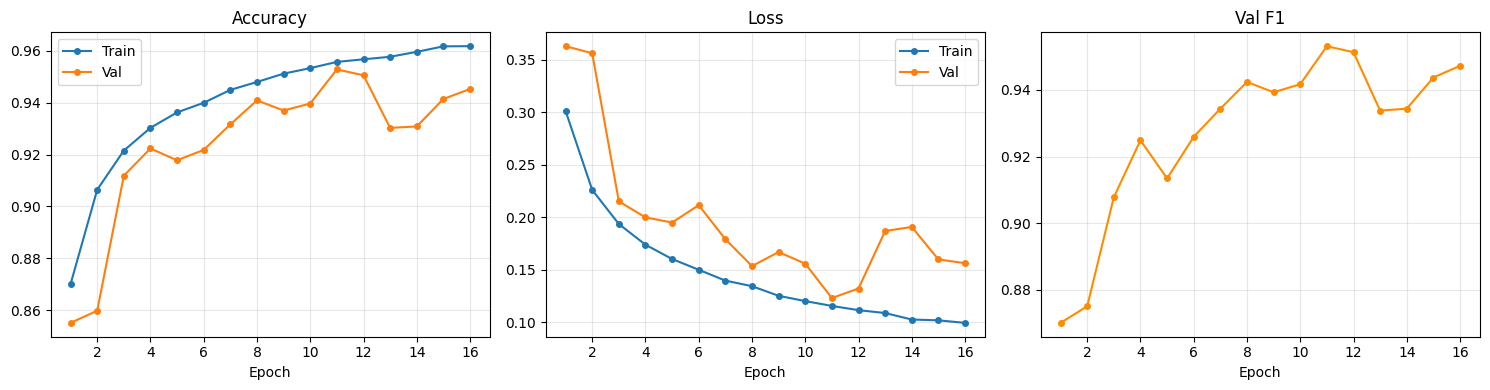

Plot saved to: /kaggle/working/training_curves.png


In [9]:
import matplotlib.pyplot as plt

ep          = [h['epoch']          for h in history]
train_acc   = [h['train_accuracy'] for h in history]
val_acc     = [h['val_accuracy']   for h in history]
train_loss  = [h['train_loss']     for h in history]
val_loss    = [h['val_loss']       for h in history]
val_f1_hist = [h['val_f1']         for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, train_acc,  label='Train', marker='o', markersize=4)
axes[0].plot(ep, val_acc,    label='Val',   marker='o', markersize=4)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_loss, label='Train', marker='o', markersize=4)
axes[1].plot(ep, val_loss,   label='Val',   marker='o', markersize=4)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, val_f1_hist, color='darkorange', marker='o', markersize=4)
axes[2].set_title('Val F1')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = '/kaggle/working/training_curves.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot saved to: {plot_path}')


## Cell 10 — Output files

In [10]:
import os

output_files = [
    '/kaggle/working/model.pt',
    '/kaggle/working/training_log.csv',
    '/kaggle/working/training_curves.png',
]

print('Output files saved to /kaggle/working/')
print('Download them from the Output tab on the right panel.\n')
for f in output_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1e6
        print(f'  {os.path.basename(f):<25s}  {size:.1f} MB')
    else:
        print(f'  {os.path.basename(f):<25s}  not found')


Output files saved to /kaggle/working/
Download them from the Output tab on the right panel.

  model.pt                   226.4 MB
  training_log.csv           0.0 MB
  training_curves.png        0.1 MB
